# nb01 — база расхождения: как выглядит спред и насколько сильно расходится

Задача шага (запрос пользователя): взять два актива, которые **действительно**
коинтегрированы, и глазами посмотреть — как они расходятся, как выглядит спред,
и что меняется на разных таймфреймах.

**Одна честная поправка к формулировке.** «Точно коинтегрированы» нельзя знать
заранее — это результат теста, а не свойство, видимое на глаз. Поэтому:

1. берём только **ликвидные** символы (≥ $5 млн/день) — гипотеза пользователя
   именно про ликвидные связи;
2. прогоняем тест Энгла-Грейнджера на окне отбора **2024-01 … 2025-01**;
3. рядом считаем **baseline на синтетике** (перемешанные доходности = заведомо
   независимые ряды) — чтобы знать, сколько «коинтеграций» даёт чистая случайность;
4. лучшую пару берём как экспонат и смотрим на неё, включая **окно проверки
   2025-01 … 2025-07**, которое в отборе не участвовало.

OOS (2025-07 …) остаётся запертым. Экспонат выбран **в выборке** — это витрина
механики, а не доказательство edge; статистика отбора будет в следующих шагах.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint
from itertools import combinations
import time

SELECT = ("2024-01-01", "2025-01-01")   # отбор/фит
CHECK  = ("2025-01-01", "2025-07-01")   # проверка глазами, в отборе НЕ участвует
ZWIN_H = 24 * 30                        # окно каузального rolling z: 30 дней в часах
MIN_DVOL_M = 5.0                        # порог ликвидности, $ млн/день
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]

px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6

liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
print(f"ликвидных символов (>= ${MIN_DVOL_M}M/день, без стейблов): {len(liq)}")
print(f"пар из них: {len(liq)*(len(liq)-1)//2}")
print("\n".join("  " + ", ".join(liq[i:i+9]) for i in range(0, len(liq), 9)))

lp_sel = np.log(px.loc[SELECT[0]:SELECT[1], liq]).iloc[:-1]
print(f"\nокно отбора: {lp_sel.index[0]} .. {lp_sel.index[-1]}  ({len(lp_sel)} часов)")

ликвидных символов (>= $5.0M/день, без стейблов): 43
пар из них: 903
  ARUSDT, ATOMUSDT, AVAXUSDT, BCHUSDT, BNBUSDT, BTCUSDT, CRVUSDT, DOGEUSDT, DOTUSDT
  ENSUSDT, ETCUSDT, ETHUSDT, FILUSDT, GALAUSDT, GMTUSDT, HBARUSDT, ICPUSDT, INJUSDT
  JASMYUSDT, JTOUSDT, KASUSDT, LDOUSDT, LINKUSDT, MNTUSDT, NEARUSDT, OPUSDT, ORDIUSDT
  PENDLEUSDT, PEOPLEUSDT, RUNEUSDT, SANDUSDT, SEIUSDT, STXUSDT, SUIUSDT, TIAUSDT, TONUSDT
  TRBUSDT, TRXUSDT, UNIUSDT, WLDUSDT, XLMUSDT, XMRUSDT, XRPUSDT

окно отбора: 2024-01-01 00:00:00+00:00 .. 2025-01-01 22:00:00+00:00  (8807 часов)


## 1. Скан + baseline случайности

Тест Энгла-Грейнджера: регрессируем `log(P_y)` на `log(P_x)`, берём остаток
(= спред) и проверяем ADF-тестом, стационарен ли он. `p < 0.05` = «остаток
возвращается к среднему, а не блуждает».

Направление регрессии фиксируем детерминированно (**y = менее ликвидный, x =
более ликвидный**), иначе выбор направления по лучшему p — это уже подгонка.

Baseline: те же 43 символа, но доходности **перемешаны во времени**. Это
уничтожает любую связь и любую автокорреляцию, сохраняя распределение
(включая толстые хвосты крипты). Сколько пар «пройдёт» тест на таком мусоре —
столько мы имеем права списать на случайность.

In [2]:
def half_life_bars(res: np.ndarray) -> float:
    """Half-life возврата остатка к среднему, в барах (AR(1)). NaN если не MR."""
    lag, d = res[:-1], np.diff(res)
    b = np.polyfit(lag, d, 1)[0]
    return np.nan if b >= 0 else float(-np.log(2) / np.log(1 + b))


def eg_pair(y: np.ndarray, x: np.ndarray) -> dict:
    """Engle-Granger быстрым screen'ом (maxlag=1) + beta/half-life/сигма остатка."""
    p = coint(y, x, trend="c", maxlag=1, autolag=None)[1]
    beta, const = np.polyfit(x, y, 1)
    res = y - (beta * x + const)
    return {"p": p, "beta": beta, "hl_bars": half_life_bars(res),
            "sd_bps": res.std() * 1e4}


t0 = time.time()
rows = []
for a, b in combinations(liq, 2):
    # y = менее ликвидный, x = более ликвидный (фиксировано, без выбора по p)
    ylab, xlab = (a, b) if daily_m[a] <= daily_m[b] else (b, a)
    r = eg_pair(lp_sel[ylab].values, lp_sel[xlab].values)
    rows.append({"y": ylab, "x": xlab, **r})
sc = pd.DataFrame(rows)
print(f"скан {len(sc)} пар за {time.time()-t0:.1f}s")

# --- baseline: перемешанные доходности (заведомо независимые ряды) ---
rng = np.random.default_rng(42)
rets = lp_sel.diff().dropna().values
fake = np.zeros_like(rets)
for j in range(rets.shape[1]):
    fake[:, j] = rng.permutation(rets[:, j])
fake = np.cumsum(fake, axis=0) + lp_sel.values[0]
fp = [coint(fake[:, i], fake[:, j], trend="c", maxlag=1, autolag=None)[1]
      for i, j in combinations(range(len(liq)), 2)]
fp = np.array(fp)

print("\nСКОЛЬКО ПАР ПРОХОДИТ ТЕСТ")
for thr in [0.10, 0.05, 0.01]:
    real = (sc.p < thr).sum()
    rand = (fp < thr).sum()
    print(f"  p < {thr:<5}: реальные {real:>4} ({real/len(sc)*100:5.1f}%)   "
          f"перемешанные {rand:>4} ({rand/len(fp)*100:5.1f}%)   "
          f"отношение {real/max(rand,1):5.2f}x")
print(f"\nмедианный p: реальные {sc.p.median():.3f}  перемешанные {np.median(fp):.3f}")

скан 903 пар за 1.3s



СКОЛЬКО ПАР ПРОХОДИТ ТЕСТ
  p < 0.1  : реальные  197 ( 21.8%)   перемешанные  112 ( 12.4%)   отношение  1.76x
  p < 0.05 : реальные  123 ( 13.6%)   перемешанные   56 (  6.2%)   отношение  2.20x
  p < 0.01 : реальные   30 (  3.3%)   перемешанные   13 (  1.4%)   отношение  2.31x

медианный p: реальные 0.442  перемешанные 0.428


In [3]:
top = sc.sort_values("p").head(15).copy()
top["hl_days"] = (top.hl_bars / 24).round(1)
print("ТОП-15 ПАР ПО p (окно отбора 2024)")
print(top[["y", "x", "p", "beta", "hl_days", "sd_bps"]]
      .assign(p=top.p.round(4), beta=top.beta.round(3), sd_bps=top.sd_bps.round(0))
      .to_string(index=False))

# Экспонат: лучшая по p пара с торгуемым half-life (правило объявлено ДО просмотра)
HL_LO, HL_HI = 6, 24 * 30      # от 6 часов до 30 дней
cand = sc[(sc.hl_bars > HL_LO) & (sc.hl_bars < HL_HI)].sort_values("p")
print(f"\nпар с half-life в [{HL_LO}ч, {HL_HI//24}д]: {len(cand)}")
A = cand.iloc[0]
print(f"\nЭКСПОНАТ A:  y={A.y}  x={A.x}   p={A.p:.5f}  beta={A.beta:.3f}  "
      f"HL={A.hl_bars/24:.1f}д  sd={A.sd_bps:.0f}bps")

# финалистов пере-проверяем ПОЛНЫМ тестом (autolag='AIC'), не быстрым screen'ом
print("\nпере-проверка топ-5 полным тестом (autolag=AIC):")
for _, r in sc.sort_values("p").head(5).iterrows():
    pf = coint(lp_sel[r.y].values, lp_sel[r.x].values, trend="c")[1]
    print(f"  {r.y:<11} ~ {r.x:<11} screen p={r.p:.5f}   полный p={pf:.5f}")

ТОП-15 ПАР ПО p (окно отбора 2024)
       y        x      p  beta  hl_days  sd_bps
 JTOUSDT  BCHUSDT 0.0002 0.833      5.3  1266.0
 INJUSDT ORDIUSDT 0.0003 0.771      5.5   978.0
 TRBUSDT  LDOUSDT 0.0003 0.560      8.0  1783.0
 INJUSDT   OPUSDT 0.0004 0.722      5.5   926.0
 TRBUSDT  TIAUSDT 0.0004 0.458      8.5  1889.0
 ETCUSDT  DOTUSDT 0.0006 0.700      7.4   774.0
 GMTUSDT   OPUSDT 0.0007 0.982      6.0  1010.0
  OPUSDT  SEIUSDT 0.0008 0.909      6.8  1174.0
 INJUSDT  SEIUSDT 0.0010 0.687      6.2  1022.0
SANDUSDT  ETCUSDT 0.0019 1.572      8.7  1489.0
ORDIUSDT  TIAUSDT 0.0020 0.618      7.8  1365.0
 GMTUSDT  INJUSDT 0.0021 1.233      6.9  1344.0
 TRBUSDT  SEIUSDT 0.0032 0.502     11.5  2242.0
 JTOUSDT NEARUSDT 0.0035 0.713      7.2  1377.0
 TRBUSDT  INJUSDT 0.0037 0.774     10.4  2001.0

пар с half-life в [6ч, 30д]: 484

ЭКСПОНАТ A:  y=JTOUSDT  x=BCHUSDT   p=0.00021  beta=0.833  HL=5.3д  sd=1266bps

пере-проверка топ-5 полным тестом (autolag=AIC):


  JTOUSDT     ~ BCHUSDT     screen p=0.00021   полный p=0.00099


  INJUSDT     ~ ORDIUSDT    screen p=0.00027   полный p=0.00029


  TRBUSDT     ~ LDOUSDT     screen p=0.00034   полный p=0.00081


  INJUSDT     ~ OPUSDT      screen p=0.00036   полный p=0.00121


  TRBUSDT     ~ TIAUSDT     screen p=0.00039   полный p=0.00311


## 2. Экспонат A глазами: цены, спред, z-score

Три панели, всё на 1h:
- **сверху** нормированные цены обеих ног — видно, что они ходят вместе;
- **в середине** log-спред `log(y) − β·log(x)` и горизонтальные линии
  mean ± 1σ/2σ, посчитанные **только на окне отбора** и продлённые вперёд —
  так выглядит то, на что реально смотрел бы трейдер;
- **снизу** каузальный rolling z (окно 30 дней): та же картинка, но
  нормированная на *недавнее* поведение спреда.

Красная вертикаль = конец окна отбора. Справа от неё — данные, которых при
выборе пары не было.

пара JTOUSDT / BCHUSDT,  beta=0.833 (фит на 2024)
спред на окне отбора : mean -3.9694  sd 1266 bps
спред на окне проверки: mean -4.1424 = -1.37 sd отбора
  min/max в проверке, в sd отбора: -4.50 .. +2.91
доля времени |z| > 2 (каузальный z, всё окно): 9.9%


[saved] notebooks\statarb\_out\nb01_exhibit_A.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_exhibit_A.png')

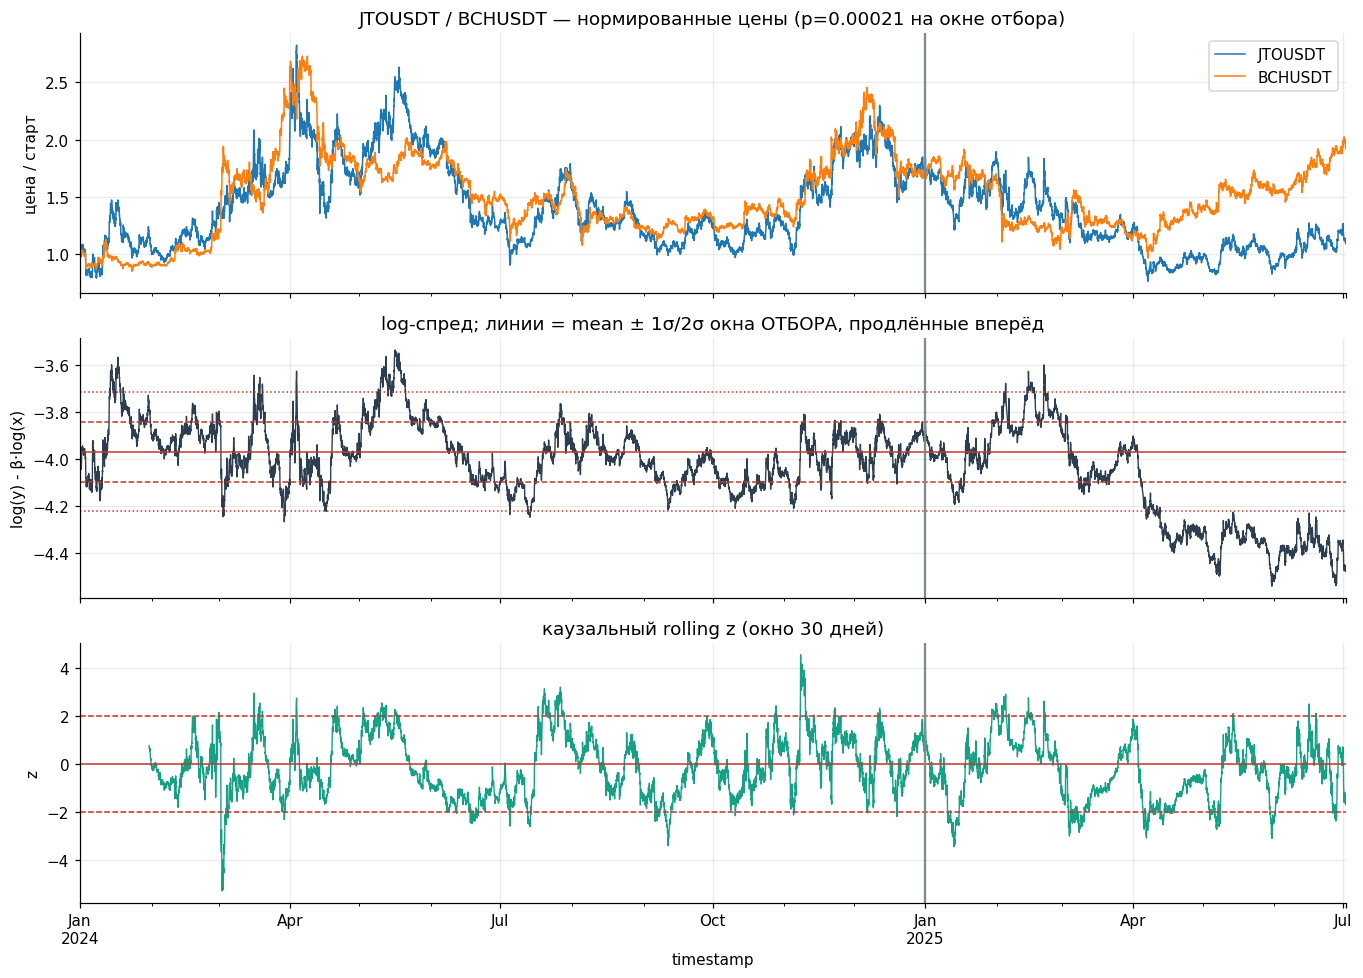

In [4]:
def build_spread(px, y, x, beta, lo, hi):
    """log-спред пары на окне [lo, hi) при ЗАДАННОЙ beta (без подгонки на этом окне)."""
    sub = px.loc[lo:hi, [y, x]].dropna()
    return np.log(sub[y]) - beta * np.log(sub[x])


s_all = build_spread(px, A.y, A.x, A.beta, SELECT[0], CHECK[1])
s_sel = s_all.loc[:SELECT[1]].iloc[:-1]
mu, sd = s_sel.mean(), s_sel.std()
zr = (s_all - s_all.rolling(ZWIN_H).mean()) / s_all.rolling(ZWIN_H).std()

print(f"пара {A.y} / {A.x},  beta={A.beta:.3f} (фит на 2024)")
print(f"спред на окне отбора : mean {mu:+.4f}  sd {sd*1e4:.0f} bps")
s_chk = s_all.loc[CHECK[0]:]
print(f"спред на окне проверки: mean {s_chk.mean():+.4f} = {(s_chk.mean()-mu)/sd:+.2f} sd отбора")
print(f"  min/max в проверке, в sd отбора: {(s_chk.min()-mu)/sd:+.2f} .. {(s_chk.max()-mu)/sd:+.2f}")
print(f"доля времени |z| > 2 (каузальный z, всё окно): {(zr.abs() > 2).mean()*100:.1f}%")

fig, ax = plt.subplots(3, 1, figsize=(12.5, 9), sharex=True)
sub = px.loc[SELECT[0]:CHECK[1], [A.y, A.x]].dropna()
(sub / sub.iloc[0]).plot(ax=ax[0], lw=1.0)
ax[0].set_title(f"{A.y} / {A.x} — нормированные цены (p={A.p:.5f} на окне отбора)")
ax[0].set_ylabel("цена / старт")

s_all.plot(ax=ax[1], lw=0.9, color="#2c3e50")
for k, st in [(0, "-"), (1, "--"), (2, ":"), (-1, "--"), (-2, ":")]:
    ax[1].axhline(mu + k*sd, color="#c0392b", ls=st, lw=1)
ax[1].set_title("log-спред; линии = mean ± 1σ/2σ окна ОТБОРА, продлённые вперёд")
ax[1].set_ylabel("log(y) - β·log(x)")

zr.plot(ax=ax[2], lw=0.9, color="#16a085")
for k in (-2, 0, 2):
    ax[2].axhline(k, color="#c0392b", ls="--" if k else "-", lw=1)
ax[2].set_title(f"каузальный rolling z (окно {ZWIN_H//24} дней)")
ax[2].set_ylabel("z")
for a_ in ax:
    a_.axvline(pd.Timestamp(SELECT[1], tz="UTC"), color="#7f8c8d", lw=1.5)
show("nb01_exhibit_A")

## 3. Тот же спред на разных таймфреймах

Ключевая мысль, которую проверяем численно: **спред — это один и тот же объект**,
таймфрейм лишь меняет частоту сэмплирования. Что реально меняется:

- половина жизни (half-life) в **барах** делится на длину бара, а в **календаре**
  должна остаться примерно той же;
- σ спреда почти не меняется (это σ *уровня*, не доходности);
- а вот окно z-score в барах — меняет смысл радикально (720 баров = 30 дней на
  1h и 720 дней на 1d), и это главная ловушка при переносе параметров между TF.

C:\Users\nvisary\AppData\Local\Temp\ipykernel_14564\3070181467.py:4: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  s = s_all if tf == "1h" else s_all.resample(tf).last().dropna()
C:\Users\nvisary\AppData\Local\Temp\ipykernel_14564\3070181467.py:18: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  corr_1h_1d = series["1h"].resample("1d").last().corr(series["1d"])


ОДИН И ТОТ ЖЕ СПРЕД, РАЗНЫЕ ТАЙМФРЕЙМЫ (окно z = 30 календарных дней везде)
TF  баров  sd_bps  HL_баров  HL_дней  z-окно_баров  переходов |z|>2  время |z|>2, %
1h  13152    1266     128.3      5.3           720              137             9.9
4h   3288    1267      32.4      5.4           180               66             9.5
1d    548    1267       5.7      5.7            30               25             7.8

corr(спред 1h, пересэмплированный в 1d; спред 1d) = 1.0000
  -> подтверждает: это одна кривая, а не разные объекты


[saved] notebooks\statarb\_out\nb01_timeframes.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_timeframes.png')

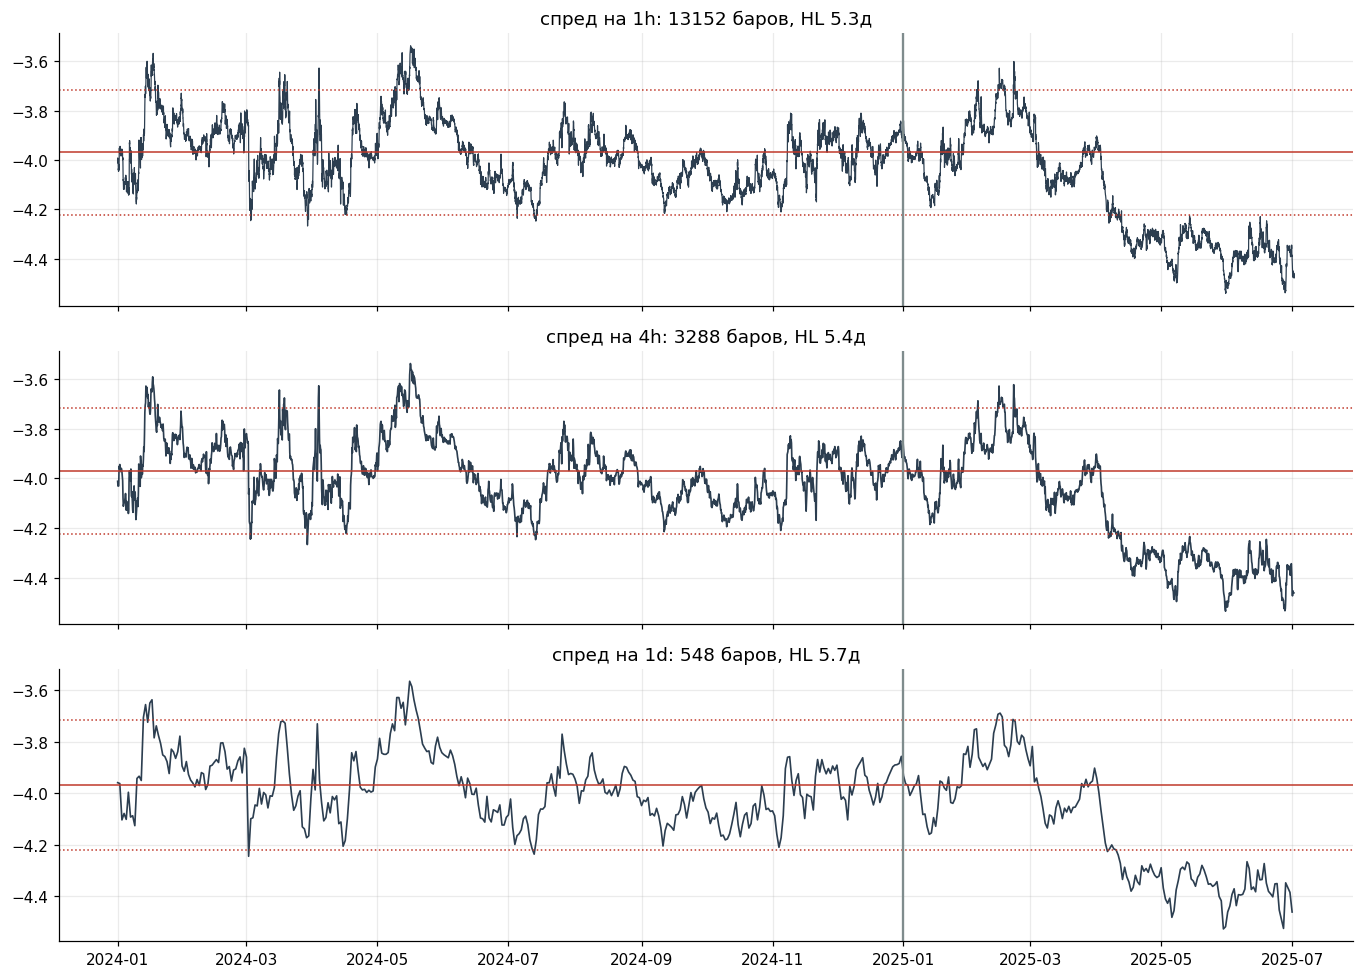

In [5]:
TFS = [("1h", 1), ("4h", 4), ("1d", 24)]
rows, series = [], {}
for tf, mult in TFS:
    s = s_all if tf == "1h" else s_all.resample(tf).last().dropna()
    series[tf] = s
    ssel = s.loc[:SELECT[1]].iloc[:-1]
    hl = half_life_bars(ssel.values)
    zc = (s - s.rolling(int(ZWIN_H / mult)).mean()) / s.rolling(int(ZWIN_H / mult)).std()
    cross = ((zc.abs() > 2) & (zc.abs().shift(1) <= 2)).sum()
    rows.append({"TF": tf, "баров": len(s), "sd_bps": round(ssel.std()*1e4),
                 "HL_баров": round(hl, 1), "HL_дней": round(hl*mult/24, 1),
                 "z-окно_баров": int(ZWIN_H/mult), "переходов |z|>2": int(cross),
                 "время |z|>2, %": round((zc.abs() > 2).mean()*100, 1)})
tfd = pd.DataFrame(rows)
print("ОДИН И ТОТ ЖЕ СПРЕД, РАЗНЫЕ ТАЙМФРЕЙМЫ (окно z = 30 календарных дней везде)")
print(tfd.to_string(index=False))

corr_1h_1d = series["1h"].resample("1d").last().corr(series["1d"])
print(f"\ncorr(спред 1h, пересэмплированный в 1d; спред 1d) = {corr_1h_1d:.4f}")
print("  -> подтверждает: это одна кривая, а не разные объекты")

fig, ax = plt.subplots(3, 1, figsize=(12.5, 9), sharex=True)
for i, (tf, mult) in enumerate(TFS):
    s = series[tf]
    ax[i].plot(s.index, s.values, lw=0.8 if tf == "1h" else 1.1, color="#2c3e50")
    for k, st in [(0, "-"), (2, ":"), (-2, ":")]:
        ax[i].axhline(mu + k*sd, color="#c0392b", ls=st, lw=1)
    ax[i].axvline(pd.Timestamp(SELECT[1], tz="UTC"), color="#7f8c8d", lw=1.5)
    ax[i].set_title(f"спред на {tf}: {len(s)} баров, HL {tfd.loc[i,'HL_дней']}д")
show("nb01_timeframes")

### 3b. Почему на разных TF спред выглядит буквально одинаково

Это правильный вопрос, и ответ в природе объекта: **спред — это УРОВЕНЬ, а не
доходность.** Пересэмплирование уровня через `.last()` не пересчитывает ничего —
оно просто **выбрасывает промежуточные точки той же кривой**. Дневная точка = один
из 24 часовых закрытий, а не среднее по дню. Поэтому 1d-кривая — это подмножество
точек 1h-кривой, и на графике длиной 18 месяцев разницу не видно (в 1000 пикселей
ширины всё равно не влезет 13 152 точки — рендерер их и так прореживает).

Отдельно признаю ошибку в §3: строка `corr(1h→1d, 1d) = 1.0000` — **тавтология**,
а не проверка: дневной ряд там построен из часового, так что корреляция обязана
быть единицей по построению. Ниже — измерения, которые реально что-то говорят:

1. **σ УРОВНЯ почти не зависит от TF, σ ДОХОДНОСТЕЙ растёт как √k.** Это и есть
   математическая причина «одинаковости»: дисперсия уровня набирается медленными
   колебаниями, а не внутридневной рябью.
2. **Что теряет дневной наблюдатель** — короткие экскурсии и внутридневные
   экстремумы (то, по чему реально сработал бы вход).
3. **Зум на один месяц** — там разница между TF наконец видна глазом.

УРОВЕНЬ ПРОТИВ ИЗМЕНЕНИЙ (почему кривые выглядят одинаково)
TF  баров  σ УРОВНЯ спреда, bps  σ ИЗМЕНЕНИЙ спреда, bps  ожидаемо √k от 1h
1h  13152                  1834                      123                123
4h   3288                  1836                      244                246
1d    548                  1836                      567                603

  σ уровня  ~ константа по TF   -> кривая та же
  σ изменений растёт как √k     -> 'шум внутри бара' просто не показан

разложение дисперсии часового спреда:
  медленная часть (дневные средние):  98.3%
  внутридневная часть              :   1.7%
  -> глаз на 18-месячном графике видит только медленную часть

экскурсий |z|>2 на 1h: 137; из них короче суток: 120 (88%)
  медиана длительности экскурсии: 3 ч; q25 1 ч

отклонение от среднего: максимум ЗА день vs на ЗАКРЫТИИ дня
  медиана max/close = 1.36x
  дней, где внутри дня отклонение было >1.5x закрытия: 39%
  -> дневной наблюдатель систематически НЕ ВИДИТ момент лучшего входа


[saved] notebooks\statarb\_out\nb01_tf_zoom.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_tf_zoom.png')

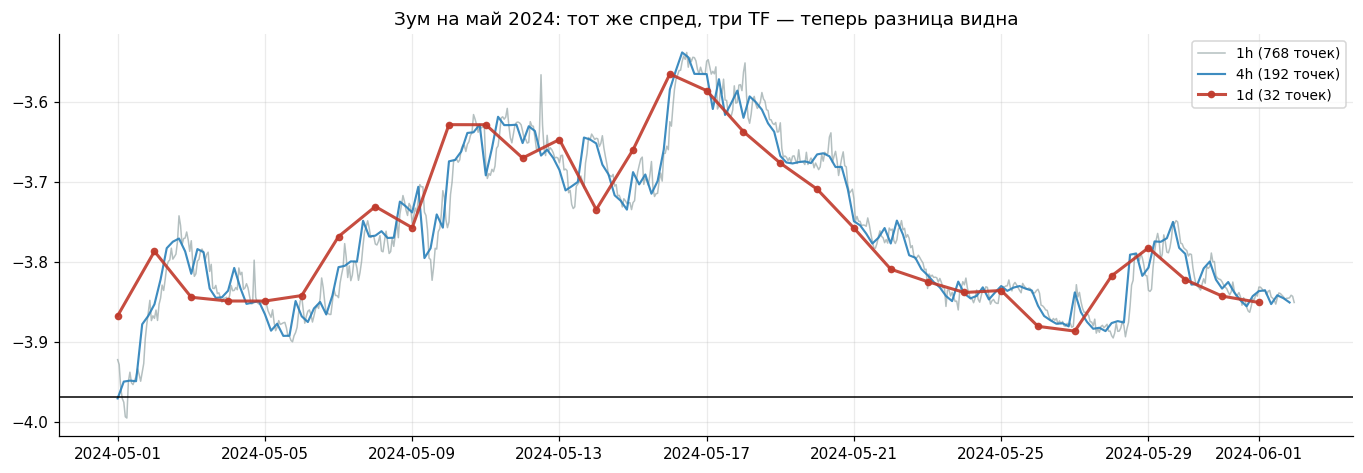

In [6]:
# --- 1) σ уровня vs σ доходностей по TF ---
rows = []
for tf, mult in TFS:
    s = series[tf]
    rows.append({"TF": tf, "баров": len(s),
                 "σ УРОВНЯ спреда, bps": round(s.std() * 1e4),
                 "σ ИЗМЕНЕНИЙ спреда, bps": round(s.diff().std() * 1e4),
                 "ожидаемо √k от 1h": round(series["1h"].diff().std() * 1e4 * np.sqrt(mult))})
print("УРОВЕНЬ ПРОТИВ ИЗМЕНЕНИЙ (почему кривые выглядят одинаково)")
print(pd.DataFrame(rows).to_string(index=False))
print("\n  σ уровня  ~ константа по TF   -> кривая та же")
print("  σ изменений растёт как √k     -> 'шум внутри бара' просто не показан")

# --- 2) сколько дисперсии живёт в медленной части ---
slow = series["1h"].resample("1D").mean().reindex(series["1h"].index, method="ffill")
fast = series["1h"] - slow
print(f"\nразложение дисперсии часового спреда:")
print(f"  медленная часть (дневные средние): {slow.var()/series['1h'].var()*100:5.1f}%")
print(f"  внутридневная часть              : {fast.var()/series['1h'].var()*100:5.1f}%")
print("  -> глаз на 18-месячном графике видит только медленную часть")

# --- 3) что теряет дневной наблюдатель ---
z1h = ((series["1h"] - series["1h"].rolling(ZWIN_H).mean())
       / series["1h"].rolling(ZWIN_H).std()).dropna()
m = z1h.abs() > 2
runs = m.groupby((m != m.shift()).cumsum()).agg(["sum", "size"])
runs = runs[runs["sum"] > 0]["size"]
print(f"\nэкскурсий |z|>2 на 1h: {len(runs)}; из них короче суток: "
      f"{(runs < 24).sum()} ({(runs < 24).mean()*100:.0f}%)")
print(f"  медиана длительности экскурсии: {runs.median():.0f} ч; q25 {runs.quantile(.25):.0f} ч")

dev = (series["1h"] - series["1h"].rolling(ZWIN_H).mean()).abs()
day_max = dev.resample("1D").max()
day_close = dev.resample("1D").last()
print(f"\nотклонение от среднего: максимум ЗА день vs на ЗАКРЫТИИ дня")
print(f"  медиана max/close = {(day_max/day_close).median():.2f}x")
print(f"  дней, где внутри дня отклонение было >1.5x закрытия: "
      f"{((day_max/day_close) > 1.5).mean()*100:.0f}%")
print("  -> дневной наблюдатель систематически НЕ ВИДИТ момент лучшего входа")

# --- 4) зум на один месяц: тут разница видна ---
zoom = ("2024-05-01", "2024-06-01")
fig, ax = plt.subplots(figsize=(12.5, 4.4))
styles = [("1h", "#95a5a6", 1.0, "-"), ("4h", "#2980b9", 1.4, "-"), ("1d", "#c0392b", 2.0, "-o")]
for tf, col, lw, st in styles:
    s = series[tf].loc[zoom[0]:zoom[1]]
    ax.plot(s.index, s.values, st, color=col, lw=lw, ms=4,
            label=f"{tf} ({len(s)} точек)", alpha=0.9 if tf != "1h" else 0.7)
ax.axhline(mu, color="black", lw=1)
ax.set_title(f"Зум на май 2024: тот же спред, три TF — теперь разница видна")
ax.legend(fontsize=9)
show("nb01_tf_zoom")

## 4. Анатомия расхождения: насколько сильно и на сколько долго

Теперь считаем то, что решает судьбу торговли спредом. Определяем **эпизод
расхождения**: начинается, когда каузальный `|z|` впервые пробивает 2, и
заканчивается, когда `|z| < 0.5` (вернулся) или кончаются данные (не вернулся).

Для каждого эпизода:
- **длительность** в часах/днях,
- **пик |z|** — насколько дальше ушло *после* входа (это то, что выбивает по стопу),
- **размер расхождения в bps** и, главное, **сколько из него отыграно** —
  выраженное в процентах от **gross notional** (`Δспред / Σ|w|`, где `w=[1,−β]`),
  потому что косты 21 bps считаются именно от gross.

Это **описание**, не стратегия: без стопов, без сайзинга, одна пара, выбранная
в выборке. Задача — увидеть порядок величин.

In [7]:
G = gross([1.0, -A.beta])          # gross notional на 1 единицу спред-позиции
print(f"gross notional на единицу позиции = |1| + |{-A.beta:.3f}| = {G:.3f}")
print(f"round-trip кост = {ROUND_TRIP_BPS} bps от gross")
print(f"  -> чтобы окупиться, спред должен пройти >= {ROUND_TRIP_BPS*G:.0f} bps в log-единицах\n")

z = zr.dropna()
s = s_all.reindex(z.index)
eps, i, n = [], 0, len(z)
zv, sv, idx = z.values, s.values, z.index
while i < n:
    if abs(zv[i]) > 2:
        sgn = np.sign(zv[i])
        j = i
        while j < n and abs(zv[j]) >= 0.5:
            j += 1
        seg = slice(i, min(j + 1, n))
        reverted = j < n
        move = (sv[i] - sv[min(j, n-1)]) * sgn        # >0 = спред сошёлся к среднему
        adverse = (np.max(sv[seg] * sgn) - sv[i] * sgn)
        eps.append({"start": idx[i], "часов": j - i, "z_вход": zv[i],
                    "пик|z|": np.max(np.abs(zv[seg])), "вернулся": reverted,
                    "сошлось_bps": move * 1e4, "против_bps": adverse * 1e4,
                    "%_от_gross": move / G * 100})
        i = j + 1
    else:
        i += 1
ep = pd.DataFrame(eps)

print(f"ЭПИЗОДОВ РАСХОЖДЕНИЯ (|z|>2 -> |z|<0.5) за {len(z)/24/365:.2f} года: {len(ep)}")
print(f"  вернулись к среднему: {ep.вернулся.sum()} из {len(ep)}")
print(f"\nДЛИТЕЛЬНОСТЬ, дней:  медиана {ep.часов.median()/24:.1f}   "
      f"q25 {ep.часов.quantile(.25)/24:.1f}  q75 {ep.часов.quantile(.75)/24:.1f}  "
      f"макс {ep.часов.max()/24:.1f}")
print(f"ПИК |z| после входа:  медиана {ep['пик|z|'].median():.1f}   "
      f"q75 {ep['пик|z|'].quantile(.75):.1f}   макс {ep['пик|z|'].max():.1f}")
print(f"ХОД ПРОТИВ (bps):     медиана {ep.против_bps.median():.0f}   "
      f"q75 {ep.против_bps.quantile(.75):.0f}   макс {ep.против_bps.max():.0f}")
print(f"\nСОШЛОСЬ, % от gross: медиана {ep['%_от_gross'].median():+.2f}%   "
      f"среднее {ep['%_от_gross'].mean():+.2f}%   "
      f"мин {ep['%_от_gross'].min():+.2f}%  макс {ep['%_от_gross'].max():+.2f}%")
net = ep['%_от_gross'] - ROUND_TRIP_BPS/100
print(f"минус косты {ROUND_TRIP_BPS/100:.2f}%: медиана {net.median():+.2f}%   "
      f"среднее {net.mean():+.2f}%   доля прибыльных {(net>0).mean()*100:.0f}%")
print(f"\nсколько эпизодов вообще не покрывают косты: {(ep['%_от_gross'] <= ROUND_TRIP_BPS/100).sum()} из {len(ep)}")
print("\nвсе эпизоды:")
print(ep.assign(start=ep.start.dt.strftime("%Y-%m-%d"), дней=(ep.часов/24).round(1))
        .round(2)[["start", "дней", "z_вход", "пик|z|", "вернулся", "сошлось_bps",
                   "против_bps", "%_от_gross"]].to_string(index=False))

gross notional на единицу позиции = |1| + |-0.833| = 1.833
round-trip кост = 21.0 bps от gross
  -> чтобы окупиться, спред должен пройти >= 38 bps в log-единицах

ЭПИЗОДОВ РАСХОЖДЕНИЯ (|z|>2 -> |z|<0.5) за 1.42 года: 33
  вернулись к среднему: 33 из 33

ДЛИТЕЛЬНОСТЬ, дней:  медиана 3.4   q25 1.5  q75 6.1  макс 21.7
ПИК |z| после входа:  медиана 2.5   q75 2.9   макс 5.3
ХОД ПРОТИВ (bps):     медиана 367   q75 1009   макс 2401

СОШЛОСЬ, % от gross: медиана +5.09%   среднее +4.75%   мин -6.42%  макс +12.48%
минус косты 0.21%: медиана +4.88%   среднее +4.54%   доля прибыльных 88%

сколько эпизодов вообще не покрывают косты: 4 из 33

все эпизоды:
     start  дней  z_вход  пик|z|  вернулся  сошлось_bps  против_bps  %_от_gross
2024-03-01   6.1    2.14    5.28      True      1709.02        0.00        9.32
2024-03-16   5.0    2.37    2.94      True      1746.53      662.26        9.53
2024-03-29   2.5   -2.22    2.31      True      2021.97      116.80       11.03
2024-04-03   0.8    2.29    2.

[saved] notebooks\statarb\_out\nb01_anatomy.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_anatomy.png')

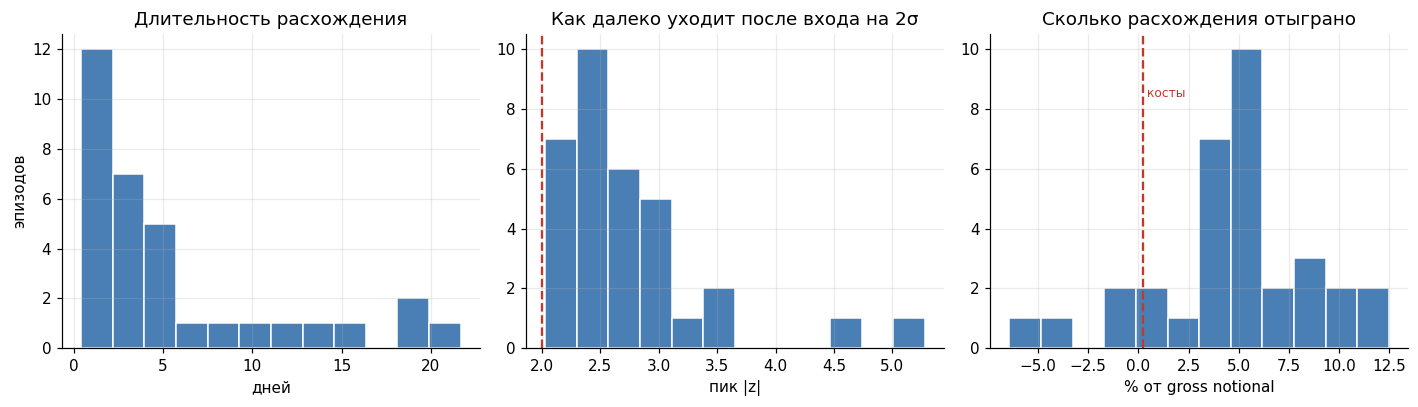

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].hist(ep.часов/24, bins=12, color="#4a7fb5", edgecolor="white")
ax[0].set_xlabel("дней"); ax[0].set_ylabel("эпизодов"); ax[0].set_title("Длительность расхождения")
ax[1].hist(ep["пик|z|"], bins=12, color="#4a7fb5", edgecolor="white")
ax[1].axvline(2, color="#c0392b", ls="--"); ax[1].set_xlabel("пик |z|")
ax[1].set_title("Как далеко уходит после входа на 2σ")
ax[2].hist(ep["%_от_gross"], bins=12, color="#4a7fb5", edgecolor="white")
ax[2].axvline(ROUND_TRIP_BPS/100, color="#c0392b", ls="--")
ax[2].text(ROUND_TRIP_BPS/100, ax[2].get_ylim()[1]*0.8, " косты", color="#c0392b", fontsize=8)
ax[2].set_xlabel("% от gross notional"); ax[2].set_title("Сколько расхождения отыграно")
show("nb01_anatomy")

## 5. Контр-пример: пара, которая «ходит вместе» на глаз, но не коинтегрирована

Чтобы калибровать глаз, нужен отрицательный экспонат. BTC/ETH выглядят
со-двигающимися для любого наблюдателя — проверим тестом и посмотрим на спред
рядом с экспонатом A.

ETHUSDT ~ BTCUSDT на окне отбора: p=0.668 (полный тест 0.658), beta=0.524, HL=40.8д
корреляция ЧАСОВЫХ ДОХОДНОСТЕЙ ETH/BTC: 0.811
  ^ высокая корреляция доходностей и коинтеграция уровней — РАЗНЫЕ вещи

спред ETH/BTC в окне проверки: -3.51 sd отбора (min -6.60)


[saved] notebooks\statarb\_out\nb01_counterexample.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_counterexample.png')

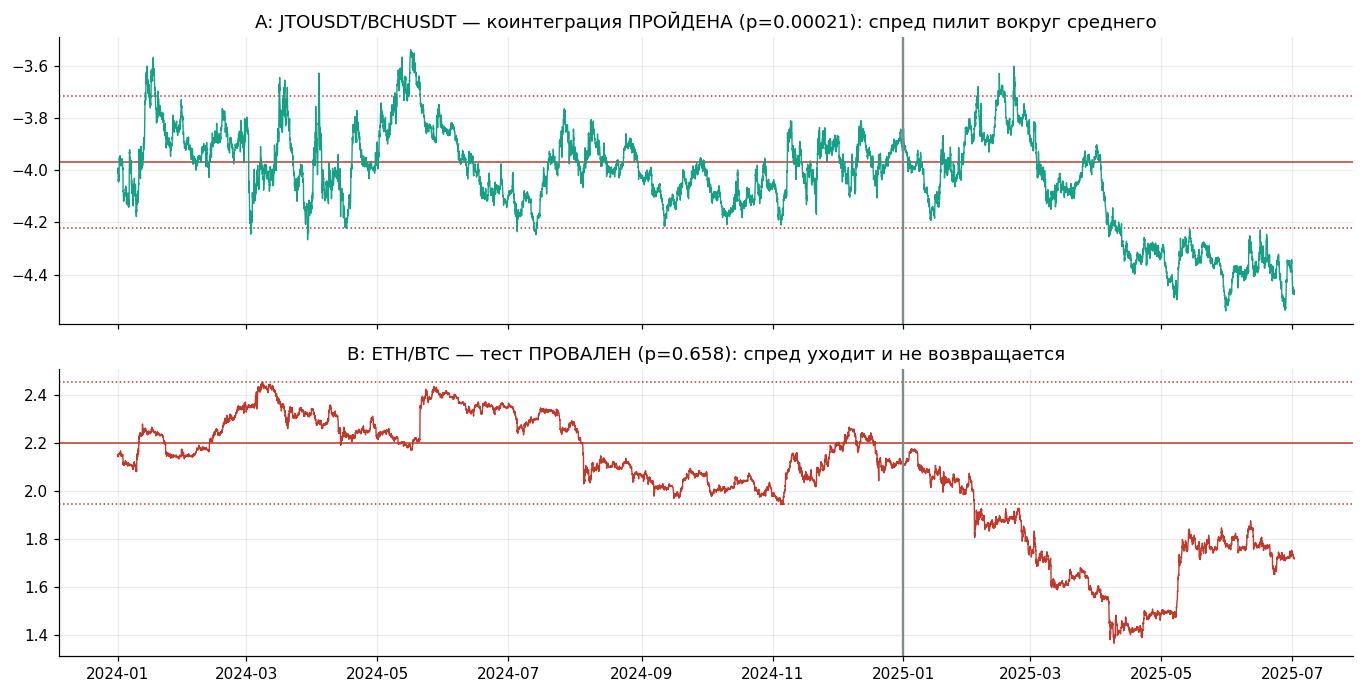

In [9]:
B = eg_pair(lp_sel["ETHUSDT"].values, lp_sel["BTCUSDT"].values)
pb_full = coint(lp_sel["ETHUSDT"].values, lp_sel["BTCUSDT"].values, trend="c")[1]
print(f"ETHUSDT ~ BTCUSDT на окне отбора: p={B['p']:.3f} (полный тест {pb_full:.3f}), "
      f"beta={B['beta']:.3f}, HL={B['hl_bars']/24:.1f}д")
print(f"корреляция ЧАСОВЫХ ДОХОДНОСТЕЙ ETH/BTC: "
      f"{lp_sel['ETHUSDT'].diff().corr(lp_sel['BTCUSDT'].diff()):.3f}")
print("  ^ высокая корреляция доходностей и коинтеграция уровней — РАЗНЫЕ вещи")

sB = build_spread(px, "ETHUSDT", "BTCUSDT", B["beta"], SELECT[0], CHECK[1])
sB_sel = sB.loc[:SELECT[1]].iloc[:-1]
muB, sdB = sB_sel.mean(), sB_sel.std()
print(f"\nспред ETH/BTC в окне проверки: {(sB.loc[CHECK[0]:].mean()-muB)/sdB:+.2f} sd отбора "
      f"(min {(sB.loc[CHECK[0]:].min()-muB)/sdB:+.2f})")

fig, ax = plt.subplots(2, 1, figsize=(12.5, 6.4), sharex=True)
for k, st in [(0, "-"), (2, ":"), (-2, ":")]:
    ax[0].axhline(mu + k*sd, color="#c0392b", ls=st, lw=1)
    ax[1].axhline(muB + k*sdB, color="#c0392b", ls=st, lw=1)
ax[0].plot(s_all.index, s_all.values, lw=0.9, color="#16a085")
ax[0].set_title(f"A: {A.y}/{A.x} — коинтеграция ПРОЙДЕНА (p={A.p:.5f}): спред пилит вокруг среднего")
ax[1].plot(sB.index, sB.values, lw=0.9, color="#c0392b")
ax[1].set_title(f"B: ETH/BTC — тест ПРОВАЛЕН (p={pb_full:.3f}): спред уходит и не возвращается")
for a_ in ax:
    a_.axvline(pd.Timestamp(SELECT[1], tz="UTC"), color="#7f8c8d", lw=1.5)
show("nb01_counterexample")

## 6. Обязательный baseline: а цифра «+5% за эпизод» вообще что-то значит?

В §4 получилось, что медианный эпизод отыгрывает **+5% от gross**, и 88%
эпизодов бьют косты. Прежде чем радоваться, надо исключить два способа получить
такую цифру из ничего:

1. **Отбор.** Экспонат A — лучшая пара из 903 на том же окне. Лучшая по
   стационарности почти по определению даст красивую картинку эпизодов.
2. **Артефакт самой метрики.** Мы входим по `|z|>2` и выходим по `|z|<0.5`, где
   `z` — *rolling*. `|z|` может упасть не потому, что спред вернулся, а потому что
   30-дневное среднее **догнало** спред. Тогда «эпизод закрылся» без реального
   возврата, и знак PnL определяется чем угодно.

Поэтому прогоняем ту же процедуру на трёх группах:
- **все 903 реальные пары**, разбитые на коинтегрированные (`p<0.05` на окне
  отбора) и остальные;
- **903 синтетические пары** из перемешанных доходностей — там связи нет
  вообще **по построению**, так что любой плюс здесь = чистый артефакт метрики.

Если у синтетики медиана тоже ~+5%, то в §4 мы измерили не edge, а свою линейку.

In [10]:
def episodes_of(s: pd.Series, g: float, zwin: int = ZWIN_H,
                zin: float = 2.0, zout: float = 0.5) -> pd.DataFrame:
    """Эпизоды расхождения одной серии-спреда.

    Возвращает для каждого эпизода:
      hours          длительность в барах (1h)
      pct_gross      реально отыгранный ход спреда, % от gross notional `g`
      sigma_captured тот же ход, но в единицах σ спреда НА ВХОДЕ (rolling sd)
      sd_pct_gross   сама σ на входе, % от gross  (масштаб выплаты)
    Знак положительный = спред реально сошёлся к своему среднему.
    Нормировка на σ обязательна: у разных пар (и у синтетики) разная волатильность
    спреда, и без неё сравнение групп сравнивает волатильность, а не возврат.
    """
    m = s.rolling(zwin).mean()
    sd = s.rolling(zwin).std()
    z = ((s - m) / sd).dropna()
    sv = s.reindex(z.index).values
    sdv = sd.reindex(z.index).values
    zv = z.values
    n = len(zv)
    out, i = [], 0
    while i < n:
        if abs(zv[i]) > zin:
            sgn = np.sign(zv[i])
            j = i
            while j < n and abs(zv[j]) >= zout:
                j += 1
            k = min(j, n - 1)
            move = (sv[i] - sv[k]) * sgn
            out.append({"start": z.index[i], "hours": j - i, "pct_gross": move / g * 100,
                        "sigma_captured": move / sdv[i],
                        "sd_pct_gross": sdv[i] / g * 100, "reverted": j < n})
            i = j + 1
        else:
            i += 1
    return pd.DataFrame(out)


COST_PCT = ROUND_TRIP_BPS / 100

# --- спреды всех реальных пар на TRAIN, beta с окна отбора ---
lp_tr = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
t0 = time.time()
real_eps = []
for _, r in sc.iterrows():
    e = episodes_of(lp_tr[r.y] - r.beta * lp_tr[r.x], 1 + abs(r.beta))
    if len(e):
        e["p"] = r.p
        e["pair"] = f"{r.y}/{r.x}"
        real_eps.append(e)
real_eps = pd.concat(real_eps, ignore_index=True)
print(f"реальные пары: {len(real_eps)} эпизодов за {time.time()-t0:.0f}s")

# --- синтетика: перемешанные доходности (связи нет ПО ПОСТРОЕНИЮ) ---
rng2 = np.random.default_rng(7)
rets_tr = lp_tr.diff().dropna().values
fake_tr = np.zeros_like(rets_tr)
for j in range(rets_tr.shape[1]):
    fake_tr[:, j] = rng2.permutation(rets_tr[:, j])
fake_tr = pd.DataFrame(np.cumsum(fake_tr, axis=0) + lp_tr.values[0],
                       index=lp_tr.index[1:], columns=liq)
fake_sel = fake_tr.loc[:SELECT[1]].iloc[:-1]

t0 = time.time()
fake_eps = []
for a, b in combinations(liq, 2):
    ylab, xlab = (a, b) if daily_m[a] <= daily_m[b] else (b, a)
    beta = np.polyfit(fake_sel[xlab].values, fake_sel[ylab].values, 1)[0]
    e = episodes_of(fake_tr[ylab] - beta * fake_tr[xlab], 1 + abs(beta))
    if len(e):
        e["pair"] = f"{ylab}/{xlab}"
        fake_eps.append(e)
fake_eps = pd.concat(fake_eps, ignore_index=True)
print(f"синтетика:     {len(fake_eps)} эпизодов за {time.time()-t0:.0f}s")


def summ(e: pd.DataFrame, tag: str) -> dict:
    net = e.pct_gross - COST_PCT
    return {"группа": tag, "эпизодов": len(e),
            "мед σ": round(e.sigma_captured.median(), 2),
            "СРЕД σ": round(e.sigma_captured.mean(), 2),
            "σ спреда %gross": round(e.sd_pct_gross.median(), 2),
            "мед %gross": round(e.pct_gross.median(), 2),
            "СРЕД %gross": round(e.pct_gross.mean(), 2),
            "СРЕД net%": round(net.mean(), 2),
            "% приб": round((net > 0).mean() * 100, 1),
            "мед дней": round(e.hours.median() / 24, 1)}


A_eps = episodes_of(s_all.loc[TRAIN[0]:TRAIN[1]], gross([1.0, -A.beta]))
coint_eps = real_eps[real_eps.p < 0.05]
nonco_eps = real_eps[real_eps.p >= 0.05]
groups = [(A_eps, "экспонат A (best-of-903)"),
          (coint_eps, f"реальные p<0.05 ({(sc.p<0.05).sum()} пар)"),
          (nonco_eps, f"реальные p>=0.05 ({(sc.p>=0.05).sum()} пар)"),
          (fake_eps, "СИНТЕТИКА (связи нет)")]
print("\nТА ЖЕ ПРОЦЕДУРА НА РАЗНЫХ ГРУППАХ (пул эпизодов, TRAIN, косты 0.21% от gross)")
print(pd.DataFrame([summ(e, t) for e, t in groups]).to_string(index=False))

print("\nКак читать:")
print("  'σ' = сколько сигм расхождения реально отыграно — мера ВОЗВРАТА, очищенная")
print("        от волатильности (единственное честное сравнение групп между собой).")
print("  '%gross' = те же деньги в % от ноцинала; зависит И от возврата, И от того,")
print("        насколько широкий спред у пары.")
print("  МЕДИАНА vs СРЕДНЕЕ: медиана = типичный эпизод; среднее включает хвост")
print("        (эпизоды, где спред не вернулся, а улетел). Решает СРЕДНЕЕ.")

fm, fs = fake_eps.sigma_captured.median(), fake_eps.sigma_captured.mean()
print("\nПРЕВЫШЕНИЕ ВОЗВРАТА (в σ) НАД СИНТЕТИКОЙ:")
for e, t in groups[:3]:
    print(f"  {t:<28} медиана {e.sigma_captured.median() - fm:+.3f}σ   "
          f"среднее {e.sigma_captured.mean() - fs:+.3f}σ")
print(f"  (уровень синтетики: медиана {fm:+.2f}σ, среднее {fs:+.2f}σ)")

print("\nСКОЛЬКО СТОЯТ КОСТЫ ОТНОСИТЕЛЬНО σ (реальные пары):")
sdm = real_eps.sd_pct_gross.median()
print(f"  медианная σ спреда = {sdm:.2f}% от gross = {sdm*100:.0f} bps")
print(f"  round-trip кост    = {COST_PCT:.2f}% от gross = {ROUND_TRIP_BPS:.0f} bps")
print(f"  -> кост = {COST_PCT/sdm:.3f}σ; при входе на 2σ и выходе на 0.5σ "
      f"теоретический ход 1.5σ, косты съедают {COST_PCT/sdm/1.5*100:.1f}% от него")

реальные пары: 21784 эпизодов за 2s


синтетика:     21594 эпизодов за 2s

ТА ЖЕ ПРОЦЕДУРА НА РАЗНЫХ ГРУППАХ (пул эпизодов, TRAIN, косты 0.21% от gross)
                    группа  эпизодов  мед σ  СРЕД σ  σ спреда %gross  мед %gross  СРЕД %gross  СРЕД net%  % приб  мед дней
  экспонат A (best-of-903)        33   1.35    1.18             3.60        5.09         4.75       4.54    87.9       3.4
 реальные p<0.05 (123 пар)      3104   1.18    0.39             3.71        3.26         1.25       1.04    72.9       6.4
реальные p>=0.05 (780 пар)     18680   1.02   -0.05             3.63        2.81         0.22       0.01    71.0       7.4
     СИНТЕТИКА (связи нет)     21594   0.98    0.20             5.87        5.14         1.27       1.06    69.5       7.6

Как читать:
  'σ' = сколько сигм расхождения реально отыграно — мера ВОЗВРАТА, очищенная
        от волатильности (единственное честное сравнение групп между собой).
  '%gross' = те же деньги в % от ноцинала; зависит И от возврата, И от того,
        насколько широкий 

СРЕДНИЙ ЗАХВАТ σ, агрегировано ПО ПАРАМ (n = число пар, не эпизодов)
          группа  пар  средний σ-захват  std между парами    SE  % пар с плюсом
 реальные p<0.05  123             0.309             0.548 0.049            71.5
реальные p>=0.05  780            -0.118             0.714 0.026            48.3
       СИНТЕТИКА  903             0.151             0.479 0.016            65.4

разница (коинтегрированные − синтетика) = +0.157σ,  SE 0.052,  t = 3.03
разница (p>=0.05 − синтетика)          = -0.270σ

экспонат A на этом фоне:
  средний σ-захват +1.18 — это 99-й перцентиль среди 903 реальных пар (n=33 эпизода, выбран как лучший из 903 => bias)
[saved] notebooks\statarb\_out\nb01_baseline.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb01_baseline.png')

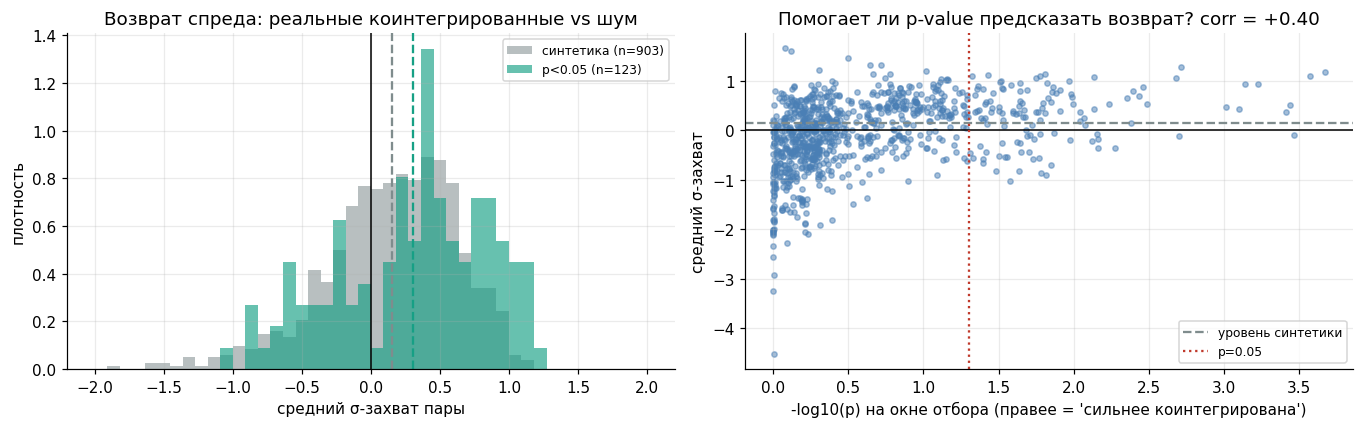

In [11]:
# 21 784 эпизода — это НЕ 21 784 независимых наблюдения: 43 символа дают 903 пары,
# которые делят ноги, а эпизоды разных пар происходят в одни и те же дни рынка.
# Поэтому сравниваем на уровне ПАР (одна пара = одно наблюдение), где n честный.
per_real = (real_eps.groupby(["pair", "p"], as_index=False)
            .agg(n_ep=("sigma_captured", "size"), mean_sig=("sigma_captured", "mean"),
                 mean_pct=("pct_gross", "mean")))
per_fake = (fake_eps.groupby("pair", as_index=False)
            .agg(n_ep=("sigma_captured", "size"), mean_sig=("sigma_captured", "mean"),
                 mean_pct=("pct_gross", "mean")))
pr_co = per_real[per_real.p < 0.05]
pr_no = per_real[per_real.p >= 0.05]

print("СРЕДНИЙ ЗАХВАТ σ, агрегировано ПО ПАРАМ (n = число пар, не эпизодов)")
rows = []
for d, tag in [(pr_co, "реальные p<0.05"), (pr_no, "реальные p>=0.05"), (per_fake, "СИНТЕТИКА")]:
    m, sd_, n = d.mean_sig.mean(), d.mean_sig.std(), len(d)
    rows.append({"группа": tag, "пар": n, "средний σ-захват": round(m, 3),
                 "std между парами": round(sd_, 3), "SE": round(sd_ / np.sqrt(n), 3),
                 "% пар с плюсом": round((d.mean_sig > 0).mean() * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))

dlt = pr_co.mean_sig.mean() - per_fake.mean_sig.mean()
se = np.sqrt(pr_co.mean_sig.var() / len(pr_co) + per_fake.mean_sig.var() / len(per_fake))
print(f"\nразница (коинтегрированные − синтетика) = {dlt:+.3f}σ,  SE {se:.3f},  t = {dlt/se:.2f}")
print(f"разница (p>=0.05 − синтетика)          = "
      f"{pr_no.mean_sig.mean() - per_fake.mean_sig.mean():+.3f}σ")
print("\nэкспонат A на этом фоне:")
aq = (per_real.mean_sig < A_eps.sigma_captured.mean()).mean() * 100
print(f"  средний σ-захват {A_eps.sigma_captured.mean():+.2f} — это {aq:.0f}-й перцентиль "
      f"среди 903 реальных пар (n=33 эпизода, выбран как лучший из 903 => bias)")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))
bins = np.linspace(-2, 2, 45)
ax[0].hist(per_fake.mean_sig, bins=bins, alpha=0.55, label=f"синтетика (n={len(per_fake)})",
           color="#7f8c8d", density=True)
ax[0].hist(pr_co.mean_sig, bins=bins, alpha=0.65, label=f"p<0.05 (n={len(pr_co)})",
           color="#16a085", density=True)
ax[0].axvline(0, color="black", lw=1)
ax[0].axvline(per_fake.mean_sig.mean(), color="#7f8c8d", ls="--", lw=1.5)
ax[0].axvline(pr_co.mean_sig.mean(), color="#16a085", ls="--", lw=1.5)
ax[0].set_xlabel("средний σ-захват пары"); ax[0].set_ylabel("плотность")
ax[0].set_title("Возврат спреда: реальные коинтегрированные vs шум")
ax[0].legend(fontsize=8)

ax[1].scatter(-np.log10(per_real.p.clip(lower=1e-6)), per_real.mean_sig, s=12, alpha=0.5,
              color="#4a7fb5")
ax[1].axhline(per_fake.mean_sig.mean(), color="#7f8c8d", ls="--", lw=1.5,
              label="уровень синтетики")
ax[1].axhline(0, color="black", lw=1)
ax[1].axvline(-np.log10(0.05), color="#c0392b", ls=":", lw=1.5, label="p=0.05")
rho = np.corrcoef(-np.log10(per_real.p.clip(lower=1e-6)), per_real.mean_sig)[0, 1]
ax[1].set_xlabel("-log10(p) на окне отбора (правее = 'сильнее коинтегрирована')")
ax[1].set_ylabel("средний σ-захват")
ax[1].set_title(f"Помогает ли p-value предсказать возврат? corr = {rho:+.2f}")
ax[1].legend(fontsize=8)
show("nb01_baseline")


### 6b. Убираем перекрытие окон: замер только на непересекающемся куске

В §6 есть загрязнение, которое я обязан снять. `p`-value считался на окне отбора
(2024), а σ-захват — на всём TRAIN, то есть **включая тот же 2024 год**. Часть
преимущества коинтегрированных пар в такой постановке гарантирована: пара попала
в группу `p<0.05` именно потому, что её спред в 2024-м пилил вокруг среднего, и мы
там же считаем её возврат.

Честный замер: эпизоды, **начавшиеся только в 2025-01 … 2025-07** (окно CHECK,
в отборе не участвовало; OOS по-прежнему заперт). β и группировка по `p` — с 2024,
применяются вперёд.

In [12]:
CHK = pd.Timestamp(CHECK[0], tz="UTC")
r_chk = real_eps[real_eps.start >= CHK]
f_chk = fake_eps[fake_eps.start >= CHK]

pc_r = (r_chk.groupby(["pair", "p"], as_index=False)
        .agg(n_ep=("sigma_captured", "size"), mean_sig=("sigma_captured", "mean")))
pc_f = (f_chk.groupby("pair", as_index=False)
        .agg(n_ep=("sigma_captured", "size"), mean_sig=("sigma_captured", "mean")))
co, no = pc_r[pc_r.p < 0.05], pc_r[pc_r.p >= 0.05]

print(f"окно замера: {CHECK[0]} .. {CHECK[1]} (в отборе НЕ участвовало)")
print(f"эпизодов: реальные {len(r_chk)}, синтетика {len(f_chk)}\n")
print("СРЕДНИЙ σ-ЗАХВАТ ПО ПАРАМ — только непересекающееся окно")
rows = []
for d, tag in [(co, "реальные p<0.05"), (no, "реальные p>=0.05"), (pc_f, "СИНТЕТИКА")]:
    rows.append({"группа": tag, "пар": len(d), "эпизодов": int(d.n_ep.sum()),
                 "средний σ-захват": round(d.mean_sig.mean(), 3),
                 "SE": round(d.mean_sig.std() / np.sqrt(len(d)), 3),
                 "% пар с плюсом": round((d.mean_sig > 0).mean() * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))

dlt = co.mean_sig.mean() - pc_f.mean_sig.mean()
se = np.sqrt(co.mean_sig.var() / len(co) + pc_f.mean_sig.var() / len(pc_f))
print(f"\nразница (коинтегрированные − синтетика) = {dlt:+.3f}σ, SE {se:.3f}, t = {dlt/se:.2f}")

rho_chk = np.corrcoef(-np.log10(pc_r.p.clip(lower=1e-6)), pc_r.mean_sig)[0, 1]
print(f"corr(-log10 p из 2024, σ-захват в 2025) = {rho_chk:+.3f}")
print("\nсравнение с загрязнённым замером из §6 (весь TRAIN, окна перекрываются):")
print(f"  перекрывающийся: разница {per_real[per_real.p<0.05].mean_sig.mean() - per_fake.mean_sig.mean():+.3f}σ, "
      f"corr {np.corrcoef(-np.log10(per_real.p.clip(lower=1e-6)), per_real.mean_sig)[0,1]:+.3f}")
print(f"  чистый          : разница {dlt:+.3f}σ, corr {rho_chk:+.3f}")

# сколько пар вообще дожило: доля пар из p<0.05, где спред в 2025 не улетел навсегда
alive = r_chk[r_chk.pair.isin(co.pair)]
print(f"\nиз {(sc.p<0.05).sum()} коинтегрированных пар эпизоды в 2025 дали {co.pair.nunique()}; "
      f"доля эпизодов, где спред НЕ вернулся к 0.5σ до конца окна: "
      f"{(~alive.reverted).mean()*100:.1f}%")

окно замера: 2025-01-01 .. 2025-07-01 (в отборе НЕ участвовало)
эпизодов: реальные 7732, синтетика 7639

СРЕДНИЙ σ-ЗАХВАТ ПО ПАРАМ — только непересекающееся окно
          группа  пар  эпизодов  средний σ-захват    SE  % пар с плюсом
 реальные p<0.05  123      1049            -0.242 0.078            36.6
реальные p>=0.05  780      6683            -0.035 0.033            56.5
       СИНТЕТИКА  903      7639             0.068 0.027            60.9

разница (коинтегрированные − синтетика) = -0.310σ, SE 0.083, t = -3.74
corr(-log10 p из 2024, σ-захват в 2025) = -0.080

сравнение с загрязнённым замером из §6 (весь TRAIN, окна перекрываются):
  перекрывающийся: разница +0.157σ, corr +0.399
  чистый          : разница -0.310σ, corr -0.080

из 123 коинтегрированных пар эпизоды в 2025 дали 123; доля эпизодов, где спред НЕ вернулся к 0.5σ до конца окна: 2.3%


---

## Выводы nb01 (все числа — из ячеек выше, не из головы)

### 1. Пара = корзина из 2 ног — подтверждено алгеброй
Спред = `Σ wᵢ·log(Pᵢ)`; у пары `w=(1,−β)`. Механика одна при любом N.

### 2. Почему спред на 1h/4h/1d выглядит одинаково (вопрос пользователя)
Спред — **уровень**, а не доходность; `.last()` при пересэмплировании просто
выбрасывает точки той же кривой.
- σ **уровня**: 1834 / 1836 / 1836 bps на 1h / 4h / 1d — практически константа.
- σ **изменений**: 123 / 244 / 567 bps — растёт как √k (ожидаемо 123 / 246 / 603).
- **98.3%** дисперсии часового спреда живёт в медленной (дневной) части, 1.7% —
  внутри дня. Глаз на 18-месячном графике видит только медленную часть.
- Что дневной наблюдатель ТЕРЯЕТ: **88%** экскурсий `|z|>2` на 1h короче суток
  (медиана 3 ч), а внутридневной максимум отклонения в медиане **1.36×** больше,
  чем на закрытии дня. То есть TF не меняет форму спреда, но меняет **что можно
  поймать входом**.
- (Признанная ошибка §3: `corr(1h→1d, 1d)=1.0000` — тавтология по построению.)

### 3. Косты — НЕ узкое место на этом горизонте
Медианная σ спреда пары = **364 bps от gross**; round-trip = **21 bps = 0.058σ**.
Вход 2σ → выход 0.5σ даёт теоретический ход 1.5σ, из которого косты съедают
**3.8%**. Формулировка «дорого, сразу 4× комиссий» на многодневном горизонте
не является главным препятствием (и, по алгебре `gross`, число ног само по себе
косты не умножает — умножает только рост gross notional).

### 4. Отбор по коинтеграции работает ТОЛЬКО в выборке — главный результат
| замер | разница (коинт. − шум) | corr(p, возврат) | % пар с плюсом |
|---|---|---|---|
| окна ПЕРЕКРЫВАЮТСЯ (весь TRAIN) | **+0.157σ** (t=3.03) | **+0.40** | 71.5% |
| окна НЕ перекрываются (2025 H1) | **−0.310σ** (t=−3.74) | **−0.08** | 36.6% |

На непересекающемся окне пары, коинтегрированные в 2024, отыгрывают **−0.242σ**
за эпизод — **хуже перемешанного шума** (+0.068σ). Знак меняется, значимость
сохраняется. Вывод: `+0.157σ` из §6 — целиком артефакт перекрытия окон.

### 5. Медиана — ловушка, среднее — судья
На синтетике **без всякой связи** медиана эпизода = **+0.98σ / +5.14% gross** и
**69.5%** «прибыльных». Любая метрика вида «вход на 2σ, выход на 0.5σ» рисует
красивую медиану на чистом случайном блуждании, потому что `|z|` падает и когда
скользящее среднее просто догоняет спред. Среднее (с хвостом невозвратов) —
единственная честная оценка.

### 6. Экспонат A как иллюстрация распада
JTO/BCH — сильнейшая из 903 пар (p=0.0002, 99-й перцентиль по σ-захвату) и при
этом экономически произвольная связка. После 2025-04 спред ушёл ниже −4σ окна
отбора и в пределах TRAIN не вернулся. Контр-пример ETH/BTC: корреляция часовых
доходностей **0.811**, а коинтеграция провалена (p=0.658) — высокая корреляция
доходностей и коинтеграция уровней это разные вещи.

### Честные ограничения
- Одно окно проверки (6 мес, 2025 H1) — направление эффекта может быть свойством
  периода; следующий шаг обязан катать замер по нескольким окнам.
- Только 43 ликвидных символа и только N=2. Корзины (N≥4) не тестировались.
- Без funding, без стопов, без сайзинга — это замер свойств спреда, не стратегия.
- OOS (2025-07 … 2026-04) не открывался.